# Préparation de la data

In [ ]:
import pandas as pd

df = pd.read_csv('billets.csv', sep=';')
df.head()


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [ ]:
# Inspecteur complet de colonnes

import pandas as pd
import numpy as np
from pathlib import Path

# --------- Paramètres ----------
FICHIER = "billets.csv"  # adapter le chemin si besoin
MAX_AFFICHAGE_VALEURS = 50                # si une colonne a <= ce nombre de valeurs uniques, on les affiche toutes
Apercu_N = 5                              # nb de lignes à afficher pour l'aperçu
# --------------------------------

def charger_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {path.resolve()}")
    # 1) essai UTF-8 (avec BOM) + auto-détection séparateur
    try:
        df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
        return df
    except UnicodeDecodeError:
        # 2) fallback Latin-1 (très courant pour fichiers FR)
        df = pd.read_csv(path, sep=None, engine="python", encoding="latin-1")
        return df

def essayer_dates(serie):
    """Tente de convertir en datetime pour repérer d'éventuelles colonnes de dates."""
    # On évite les séries très longues de texte en limitant le coût
    s = pd.to_datetime(serie, errors="coerce", dayfirst=True, infer_datetime_format=True)
    # Si au moins 70% sont des dates valides, on considère que c'est une date
    valid_ratio = s.notna().mean()
    return s if valid_ratio >= 0.7 else None

df = charger_csv(FICHIER)

print("=== Infos générales ===")
print(f"Fichier           : {FICHIER}")
print(f"Dimensions        : {df.shape[0]:,} lignes x {df.shape[1]:,} colonnes".replace(",", " "))
print("Colonnes          :", list(df.columns))
print("\n--- Aperçu (head) ---")
display(df.head(Apercu_N))
print("\n--- Aperçu (tail) ---")
display(df.tail(Apercu_N))
print("\n--- dtypes / mémoire ---")
print(df.info())

# Détection éventuelle d'une colonne 'index' à utiliser comme index
if "index" in df.columns and df["index"].is_monotonic_increasing:
    try:
        df = df.set_index("index", drop=True)
        print("\n[INFO] Colonne 'index' utilisée comme index de DataFrame.")
    except Exception:
        pass

print("\n\n================= DÉTAIL PAR COLONNE =================")
for i, col in enumerate(df.columns, start=1):
    s = df[col]
    n = len(s)
    nb_na = s.isna().sum()
    nuniq = s.nunique(dropna=True)

    print("\n" + "="*80)
    print(f"[{i}/{len(df.columns)}] Colonne : {col!r}")
    print("-"*80)
    print(f"Type pandas      : {s.dtype}")
    print(f"Lignes           : {n:,}".replace(",", " "))
    print(f"Valeurs uniques  : {nuniq:,}".replace(",", " "))
    print(f"Valeurs manquantes (NaN) : {nb_na:,}".replace(",", " "))

    # Tentative d'interprétation date si object
    parsed_dates = None
    if s.dtype == "object":
        parsed_dates = essayer_dates(s)

    # Affichage spécifique selon type/usage
    if pd.api.types.is_numeric_dtype(s):
        desc = s.describe(percentiles=[0.05, 0.5, 0.95])
        print("\n— Statistiques numériques —")
        print(desc.to_string())
        # Top 20 modalités (utile même pour numériques discrets)
        vc = s.value_counts(dropna=False).head(20)
        print("\nTop 20 fréquences :")
        print(vc.to_string())
    elif parsed_dates is not None:
        # Colonne interprétable comme dates
        print("\n— Colonne détectée comme DATE —")
        print(f"Plage : {parsed_dates.min()}  →  {parsed_dates.max()}")
        # Exemple de fréquences par année/mois si pertinent
        try:
            print("\nRépartition par année (top 20) :")
            print(parsed_dates.dt.year.value_counts(dropna=True).sort_index().tail(20).to_string())
        except Exception:
            pass
    else:
        # Catégoriel/texte
        vc = s.value_counts(dropna=False)
        if nuniq <= MAX_AFFICHAGE_VALEURS:
            print(f"\n— Toutes les valeurs distinctes (<= {MAX_AFFICHAGE_VALEURS}) —")
            # Affiche avec les effectifs pour être utile
            print(vc.to_string())
        else:
            print("\n— Extrait des valeurs (top 20) —")
            print(vc.head(20).to_string())
            # Exemple d'échantillon aléatoire de valeurs distinctes
            try:
                ech = pd.Series(s.dropna().unique())
                if len(ech) > 0:
                    sample = ech.sample(min(20, len(ech)), random_state=42).tolist()
                    print("\nÉchantillon de valeurs distinctes :", sample)
            except Exception:
                pass

print("\n\n>>> Inspection terminée.")


=== Infos générales ===
Fichier           : billets.csv
Dimensions        : 1 500 lignes x 7 colonnes
Colonnes          : ['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

--- Aperçu (head) ---


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54



--- Aperçu (tail) ---


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25
1499,False,171.47,104.15,103.82,4.63,3.37,112.07



--- dtypes / mémoire ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB
None


================= DÉTAIL PAR COLONNE =================

[1/7] Colonne : 'is_genuine'
--------------------------------------------------------------------------------
Type pandas      : bool
Lignes           : 1 500
Valeurs uniques  : 2
Valeurs manquantes (NaN) : 0

— Statistiques numériques —
count     1500
unique       2
top       True
freq      1000

Top 20 fréquences :
is_genuine
True     1000
False     500

[2/7] Col

# Regression linéaire

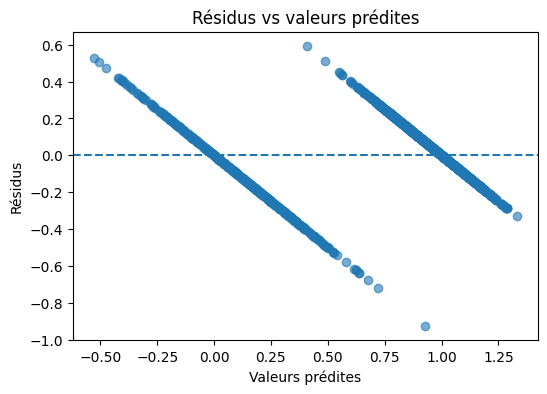

Durbin-Watson : 1.682
Breusch-Pagan p-value : 0.0000


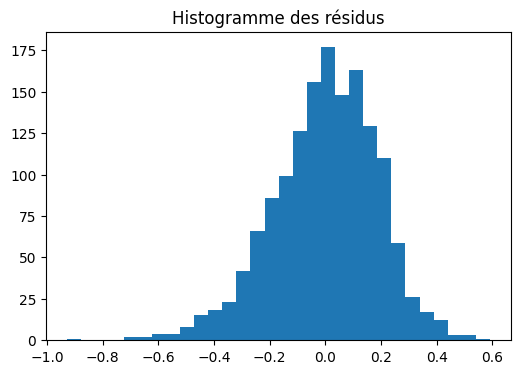

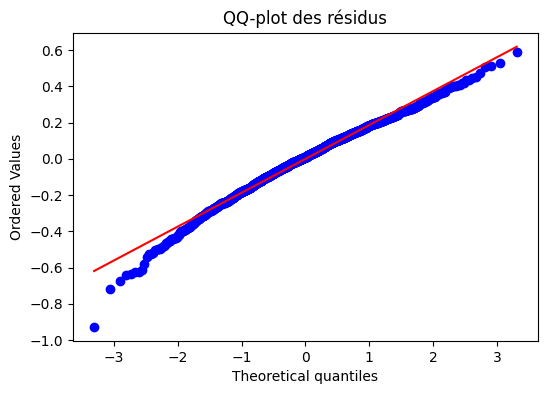

Test de normalité (D'Agostino), p-value = 0.0000


In [ ]:
#Verification d'application de la regression linéaire
import matplotlib.pyplot as plt
import numpy as np

# Re-fit du modèle sur TOUT le dataset pour les diagnostics
model.fit(X, y)
y_pred_all = model.predict(X)

# Résidus = observation - prédiction
residuals = y - y_pred_all

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_all, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")
plt.show()

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f"Durbin-Watson : {dw:.3f}")

from statsmodels.stats.diagnostic import het_breuschpagan

# On récupère les variables explicatives après prétraitement
X_trans = model.named_steps['prep'].transform(X)

# On ajoute une constante pour le test
X_bp = np.column_stack([np.ones(X_trans.shape[0]), X_trans])

bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(residuals, X_bp)
print(f"Breusch-Pagan p-value : {bp_pval:.4f}")

import scipy.stats as stats

# Histogramme des résidus
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Histogramme des résidus")
plt.show()

# QQ-plot
plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot des résidus")
plt.show()

# Test de normalité (D'Agostino)
stat, pval = stats.normaltest(residuals)
print(f"Test de normalité (D'Agostino), p-value = {pval:.4f}")



In [ ]:
import pandas as pd

# 1) Résumé par colonne : nb de NaN et %
na_summary = (
    df.isna()                          # True/False par cellule
      .agg(['sum', 'mean'])            # somme (= nb NaN) et moyenne (= part de NaN)
      .T.rename(columns={'sum':'nb_na', 'mean':'pct_na'})
)
na_summary['pct_na'] = (na_summary['pct_na'] * 100).round(2)

# 2) (Option rapide) Liste des colonnes qui ont au moins un NaN
print("\nColonnes avec au moins un NaN :", list(df.columns[df.isna().any()]))


Colonnes avec au moins un NaN : ['margin_low']


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 1) Définir X / y ---
features = ['diagonal','height_left','height_right','margin_low','margin_up']
target   = 'length'

X = df[features].copy()
y = df[target].copy()

# --- 2) Prétraitement : imputer uniquement margin_low ---
preprocess = ColumnTransformer(
    transformers=[
        # Imputer margin_low par la médiane (solide aux valeurs extrêmes),
        # + ajoute un indicateur binaire "manquant ?" (utile parfois)
        ('impute_margin_low', SimpleImputer(strategy='median', add_indicator=True), ['margin_low']),
    ],
    remainder='passthrough'  # les autres colonnes passent telles quelles
)

# --- 3) Chaîne complète : prétraitement -> régression linéaire (OLS) ---
model = Pipeline(steps=[
    ('prep', preprocess),
    ('linreg', LinearRegression())
])

# --- 4) Split entraînement / test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 5) Entraîner ---
model.fit(X_train, y_train)

# --- 6) Évaluer ---
y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²  : {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# (Optionnel) Voir les coefficients dans l’espace transformé
lin = model.named_steps['linreg']
print("Intercept :", lin.intercept_)
print("Coefficients :", lin.coef_)


R²  : 0.453
RMSE: 0.625
Intercept : 165.60536145779506
Coefficients : [-0.64781347 -0.1520372   0.06866746 -0.21527831 -0.34834354 -1.02471564]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# 1) Colonnes pour expliquer margin_low (on exclut 'length' pour éviter toute fuite d'information
#    si tu utilises ensuite ce df pour prédire 'length')
X_cols = ['diagonal','height_left','height_right','margin_up']

mask_na = df['margin_low'].isna()
if mask_na.any():
    # 2) Entraînement sur les lignes complètes pour margin_low
    X_train = df.loc[~mask_na, X_cols]
    y_train = df.loc[~mask_na, 'margin_low']

    # sécuriser au cas où X contiendrait quelques NaN
    imputer_X = SimpleImputer(strategy='median')
    X_train_imp = imputer_X.fit_transform(X_train)

    reg = LinearRegression()
    reg.fit(X_train_imp, y_train)  # OLS : minimise la somme des carrés des résidus

    # 3) Prédire margin_low pour les lignes manquantes
    X_missing = df.loc[mask_na, X_cols]
    X_missing_imp = imputer_X.transform(X_missing)
    df.loc[mask_na, 'margin_low'] = reg.predict(X_missing_imp)

    print(f"Imputation terminée : {mask_na.sum()} valeurs imputées par régression linéaire.")
else:
    print("Pas de valeurs manquantes dans margin_low.")

# Affiche les 10 premières lignes qui ont été imputées
print("\nPremières lignes imputées :")
display(df[mask_na].head(10))

Imputation terminée : 37 valeurs imputées par régression linéaire.

Premières lignes imputées :


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,4.275320,3.25,112.79
99,True,171.93,104.07,104.18,4.629997,3.14,113.08
151,True,172.07,103.80,104.38,4.499841,3.02,112.93
197,True,171.45,103.66,103.80,4.794650,3.62,113.27
241,True,171.83,104.14,104.06,4.507956,3.02,112.36
251,True,171.80,103.26,102.82,3.473371,2.95,113.22
284,True,171.92,103.83,103.76,4.401298,3.23,113.29
334,True,171.85,103.70,103.96,4.268823,3.00,113.36
410,True,172.56,103.72,103.51,4.005235,3.12,112.95
413,True,172.30,103.66,103.50,4.064349,3.16,112.95


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

X_cols = ['diagonal','height_left','height_right','margin_up']
mask_na = df['margin_low'].isna()

X = df.loc[~mask_na, X_cols]
y = df.loc[~mask_na, 'margin_low']

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('reg', LinearRegression())
])

scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
print(f"R² CV (5-fold) = {scores.mean():.4f} ± {scores.std():.4f}")

X_cols = ['diagonal','height_left','height_right','margin_up']
mask_na = df['margin_low'].isna()

X = df.loc[~mask_na, X_cols]
y = df.loc[~mask_na, 'margin_low']

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('reg', LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = -cross_val_score(pipe, X, y, cv=cv, scoring='neg_root_mean_squared_error')
print(f"RMSE CV (5-fold): {rmse_scores.mean():.4f} \u00B1 {rmse_scores.std():.4f}")

R² CV (5-fold) = -0.9263 ± 0.5603
RMSE CV (5-fold): 0.5523 ± 0.0247


In [ ]:
import pandas as pd

# 1) Résumé par colonne : nb de NaN et %
na_summary = (
    df.isna()                          # True/False par cellule
      .agg(['sum', 'mean'])            # somme (= nb NaN) et moyenne (= part de NaN)
      .T.rename(columns={'sum':'nb_na', 'mean':'pct_na'})
)
na_summary['pct_na'] = (na_summary['pct_na'] * 100).round(2)

# 2) (Option rapide) Liste des colonnes qui ont au moins un NaN
print("\nColonnes avec au moins un NaN :", list(df.columns[df.isna().any()]))


Colonnes avec au moins un NaN : []


# Analyse exploratoire

Shape: (1500, 7)

Types:
is_genuine        int64
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

Valeurs manquantes par colonne :
is_genuine      0
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

Doublons (nb de lignes dupliquées) : 0

Stats descriptives (numériques):


,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.75,171.960,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.82,104.040,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.71,103.920,104.15,104.95
margin_low,1500.0,4.483415,0.658721,2.98,4.02,4.315,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.99,3.140,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.03,112.960,113.34,114.44



Balance is_genuine (comptes):
is_genuine
1    1000
0     500
Name: count, dtype: int64

Balance is_genuine (proportions):
is_genuine
1    0.667
0    0.333
Name: proportion, dtype: float64


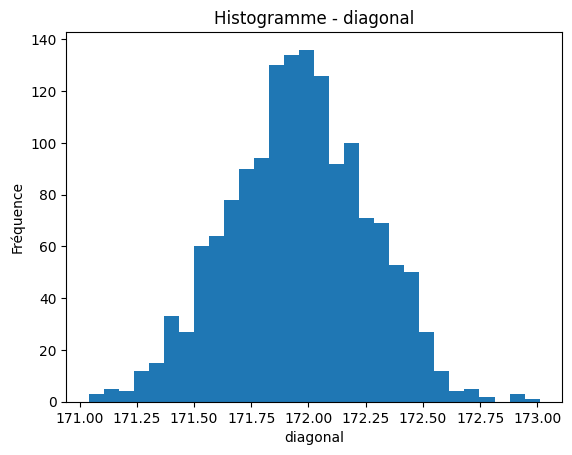

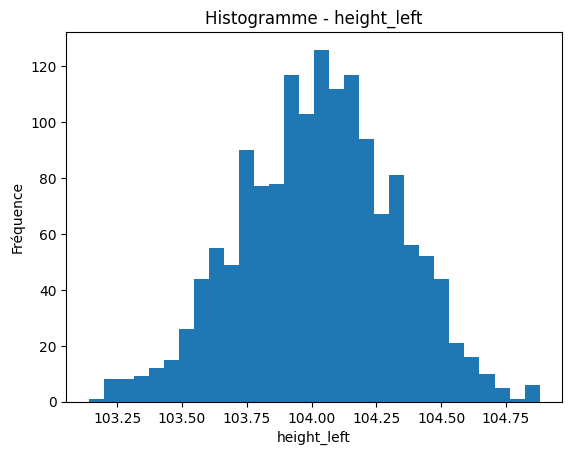

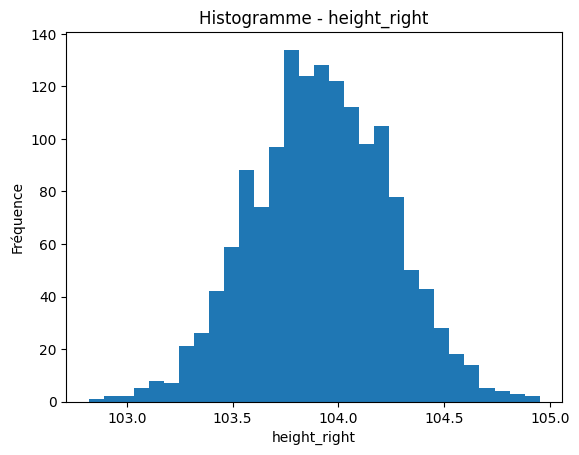

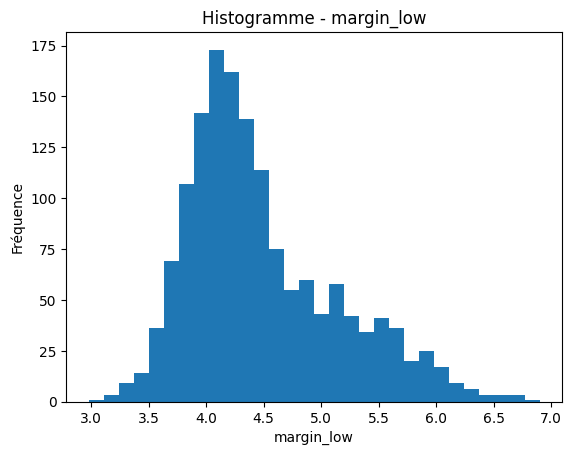

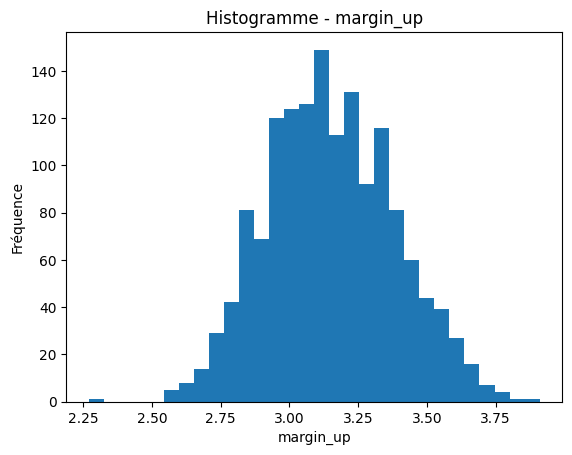

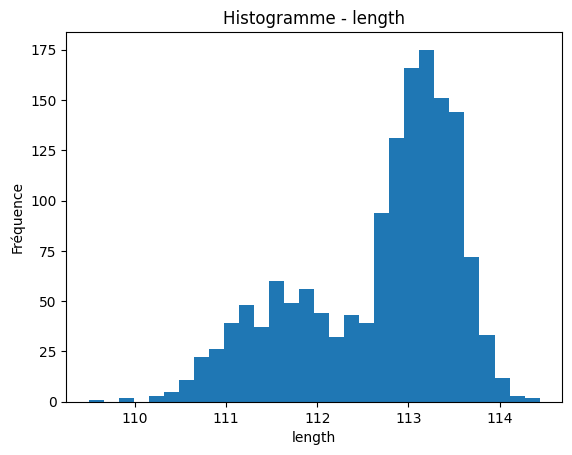

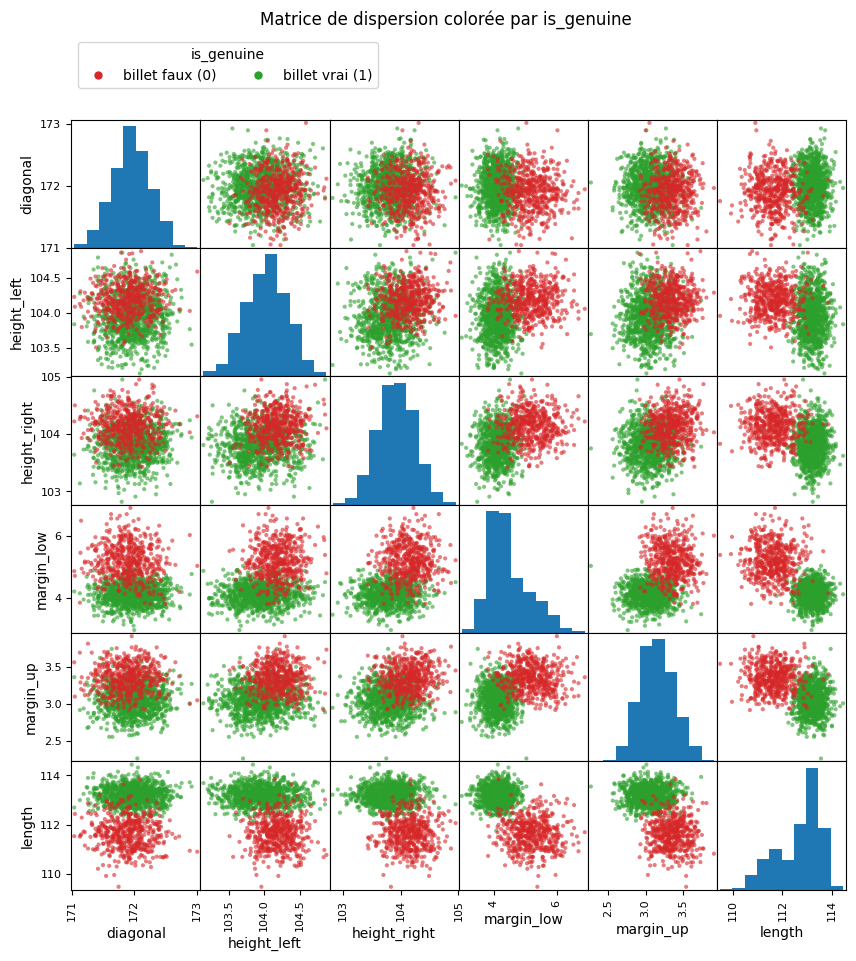

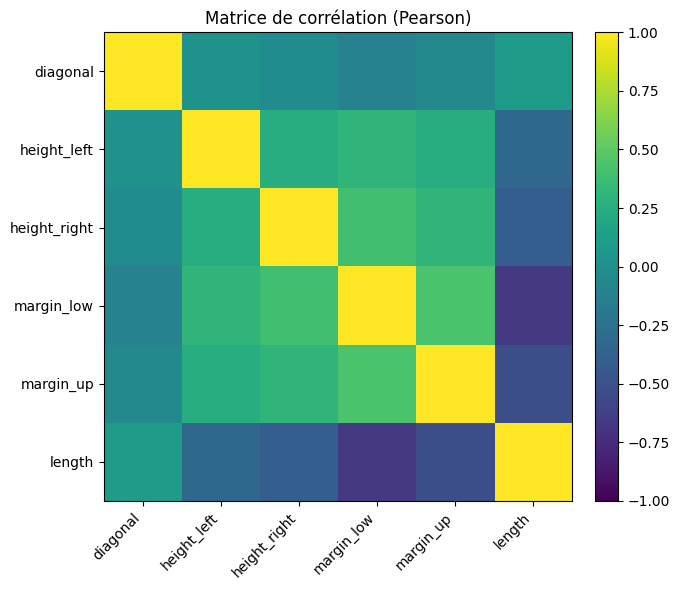

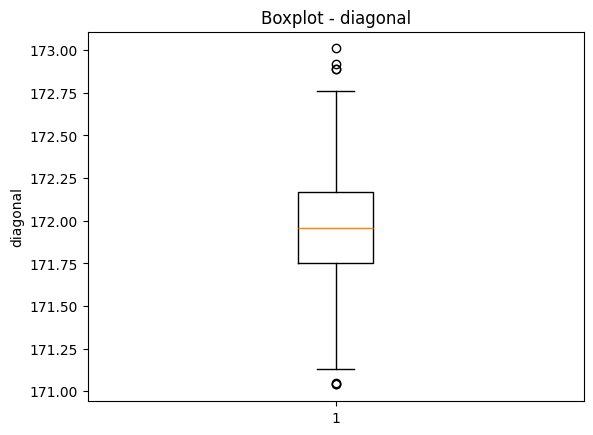

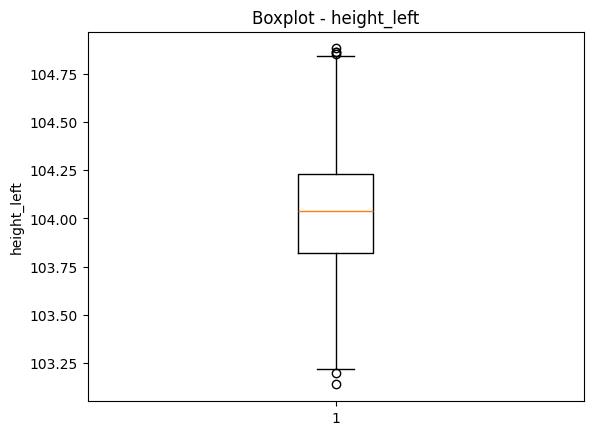

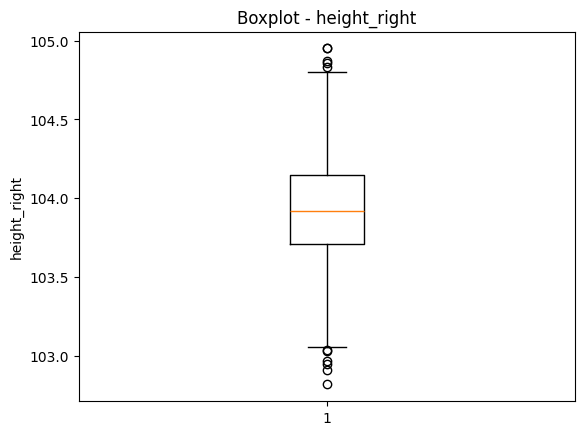

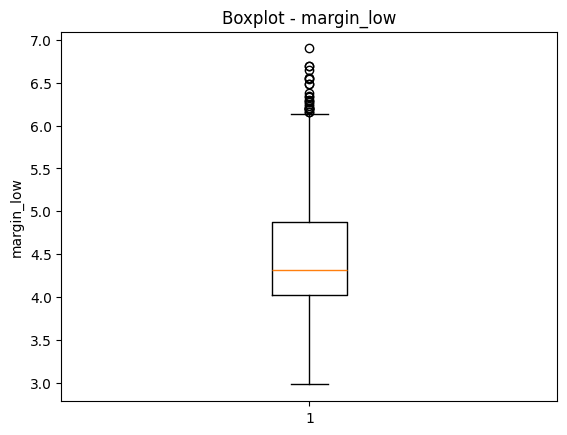

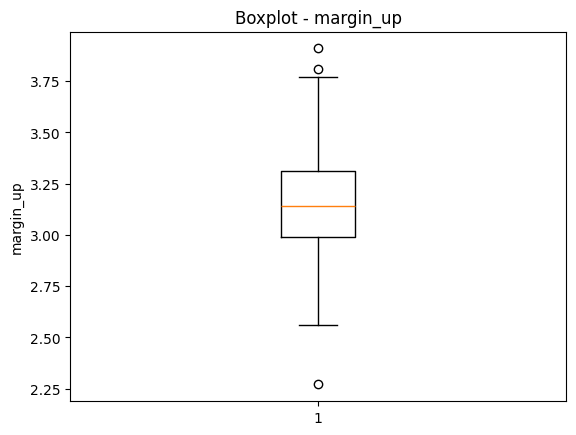

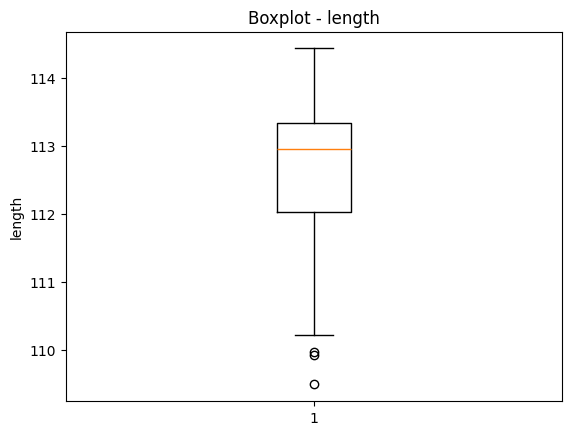

/tmp/ipython-input-2235406600.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])


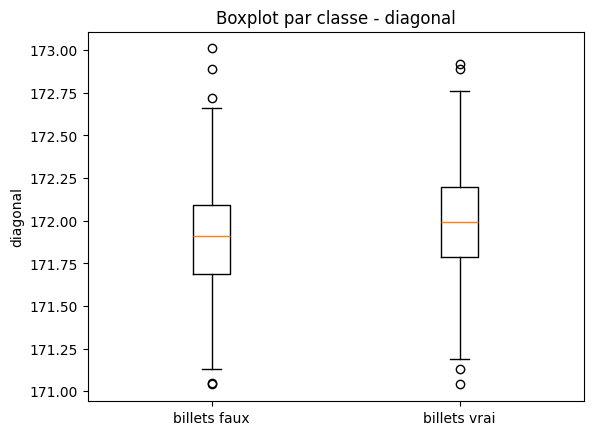

/tmp/ipython-input-2235406600.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])


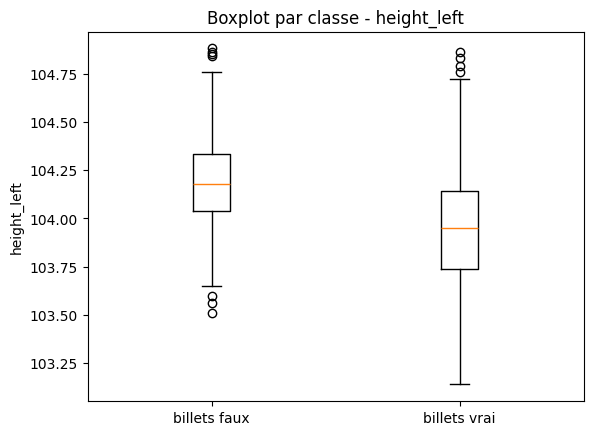

/tmp/ipython-input-2235406600.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])


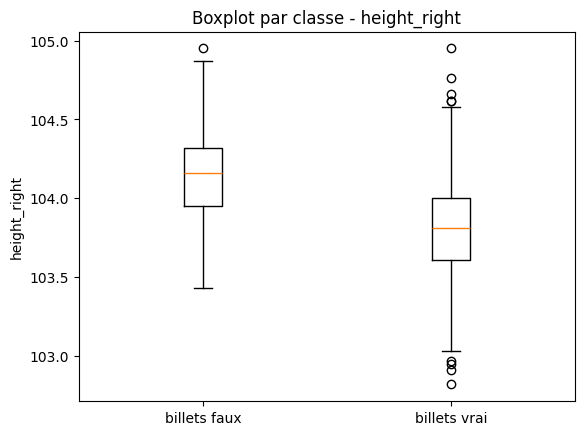

/tmp/ipython-input-2235406600.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])


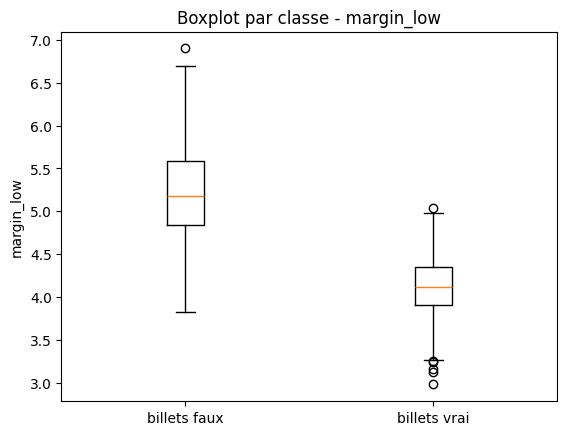

/tmp/ipython-input-2235406600.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])


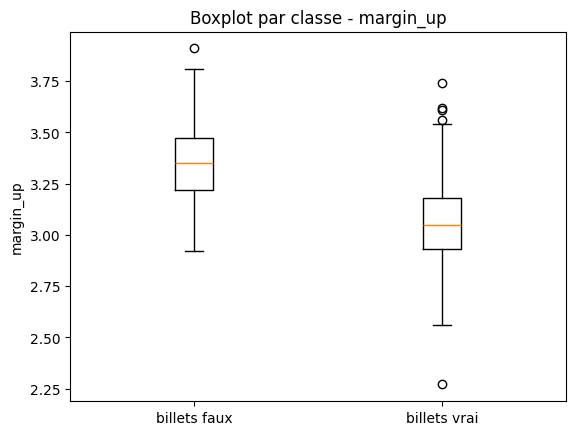

/tmp/ipython-input-2235406600.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])


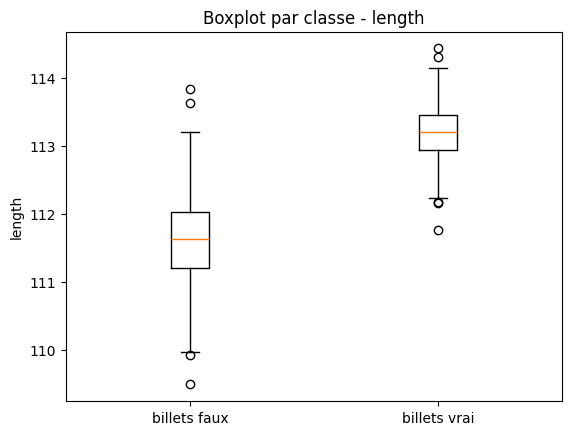


Nombre d'outliers (règle 1.5*IQR) par variable :
{'diagonal': np.int64(7), 'height_left': np.int64(6), 'height_right': np.int64(11), 'margin_low': np.int64(24), 'margin_up': np.int64(3), 'length': np.int64(3)}

VIF (plus c'est haut, plus la colinéarité est forte) :


,variable,VIF
5,length,2.109628
3,margin_low,1.914939
4,margin_up,1.421243
2,height_right,1.263529
1,height_left,1.158552
0,diagonal,1.018334


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pandas.plotting import scatter_matrix

# -------- 0) Préparation --------
df = df.copy()
df['is_genuine'] = df['is_genuine'].astype(int)

num_cols = ['diagonal','height_left','height_right','margin_low','margin_up','length']

# -------- 1) Vue d’ensemble & qualité --------
print("Shape:", df.shape)
print("\nTypes:")
print(df.dtypes)

print("\nValeurs manquantes par colonne :")
na = df.isna().sum().sort_values(ascending=False)      # isna pour NaN/None/NaT
print(na)

print("\nDoublons (nb de lignes dupliquées) :", df.duplicated().sum())

print("\nStats descriptives (numériques):")
display(df[num_cols].describe().T)                      # count/mean/std/min/percentiles/max

# -------- 2) Balance de la variable binaire --------
print("\nBalance is_genuine (comptes):")
print(df['is_genuine'].value_counts(dropna=False))

print("\nBalance is_genuine (proportions):")
print(df['is_genuine'].value_counts(normalize=True).round(3))

# -------- 3) Distributions univariées --------
# Histogrammes pour chaque variable numérique
for col in num_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogramme - {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

# -------- 4) Relations bivariées --------
# 4a) Matrice de dispersion colorée par is_genuine + légende sous le titre, alignée à GAUCHE de la grille
color_map = {0: 'tab:red', 1: 'tab:green'}
point_colors = df['is_genuine'].map(color_map)

axes = scatter_matrix(
    df[num_cols],
    figsize=(10,10),
    diagonal='hist',
    alpha=0.6,
    c=point_colors
)

fig = axes[0, 0].figure

legend_elems = [
    Line2D([0],[0], marker='o', linestyle='None', label='billet faux (0)',
           markerfacecolor=color_map[0], markeredgecolor='none'),
    Line2D([0],[0], marker='o', linestyle='None', label='billet vrai (1)',
           markerfacecolor=color_map[1], markeredgecolor='none')
]

# -- Titre et coordonnées de la grille
fig.suptitle("Matrice de dispersion colorée par is_genuine", y=0.99)

# Coordonnée gauche du 1er subplot (en coords figure)
left = axes[0,0].get_position().bounds[0]  # x0 de la grille

# Légende sous le titre, alignée sur le bord GAUCHE de la grille
fig.legend(
    handles=legend_elems,
    loc='upper left',           # coin haut-gauche de la légende posé au point ci-dessous
    ncol=2,
    title='is_genuine',
    bbox_to_anchor=(left, 0.965),  # x = bord gauche de la grille ; y = juste sous le titre
    frameon=True
)

# Laisser de la place en haut pour titre + légende
fig.subplots_adjust(top=0.88)

plt.show()

# 4b) Matrice de corrélation (Pearson)
corr = df[num_cols].corr(method='pearson')  # pearson/kendall/spearman possibles
plt.figure(figsize=(7,6))
im = plt.imshow(corr, cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.show()

# -------- 5) Outliers (boxplots & IQR) --------
# 5a) Boxplots globaux
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.show()

# 5b) Boxplots par classe (si utile visuellement)
for col in num_cols:
    plt.figure()
    data0 = df.loc[df['is_genuine']==0, col].dropna()
    data1 = df.loc[df['is_genuine']==1, col].dropna()
    plt.boxplot([data0, data1], labels=['billets faux','billets vrai'])
    plt.title(f"Boxplot par classe - {col}")
    plt.ylabel(col)
    plt.show()

# 5c) Détection IQR (compte d’outliers par variable)
def iqr_outlier_mask(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (s < low) | (s > high)

outlier_counts = {col: iqr_outlier_mask(df[col].dropna()).sum() for col in num_cols}
print("\nNombre d'outliers (règle 1.5*IQR) par variable :")
print(outlier_counts)

# -------- 6) Multicolinéarité (VIF) — optionnel --------
# Attention: VIF nécessite aucune valeur manquante
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif = df[num_cols].copy()
    # Remplissage simple pour VIF (médiane) si NaN présents
    for c in num_cols:
        X_vif[c] = X_vif[c].fillna(X_vif[c].median())
    # Ajout d'un intercept pour stabilité
    X_mat = np.column_stack([np.ones(len(X_vif))] + [X_vif[c].values for c in num_cols])
    vif_vals = []
    for i, c in enumerate(['intercept'] + num_cols):
        if c == 'intercept':
            continue
        vif_vals.append((c, variance_inflation_factor(X_mat, i)))
    vif_df = pd.DataFrame(vif_vals, columns=['variable','VIF']).sort_values('VIF', ascending=False)
    print("\nVIF (plus c'est haut, plus la colinéarité est forte) :")
    display(vif_df)
except Exception as e:
    print("VIF non calculé (statsmodels manquant ou autre souci) :", e)


In [ ]:
!pip -q install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Billets — EDA", explorative=True)
profile.to_notebook_iframe()        # ou profile.to_file("eda_billets.html")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df.describe().round(2)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,0.67,171.96,104.03,103.92,4.48,3.15,112.68
std,0.47,0.31,0.30,0.33,0.66,0.23,0.87
min,0.00,171.04,103.14,102.82,2.98,2.27,109.49
25%,0.00,171.75,103.82,103.71,4.02,2.99,112.03
50%,1.00,171.96,104.04,103.92,4.31,3.14,112.96
75%,1.00,172.17,104.23,104.15,4.87,3.31,113.34
max,1.00,173.01,104.88,104.95,6.90,3.91,114.44


# Kmeans

Volumes -> train: 1200 | test: 300


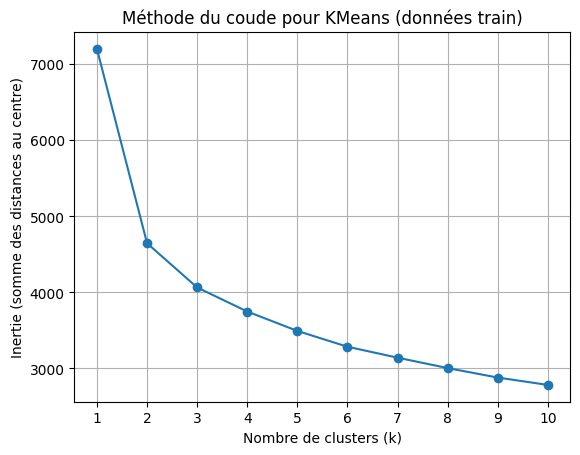

Itérations KMeans (convergence): 5

[Contingence TRAIN - true vs cluster]
 cluster    0    1
true             
0        388   12
1          6  794

[Contingence TEST  - true vs cluster]
 cluster   0    1
true            
0        98    2
1         2  198

Mapping cluster->classe (dérivé sur TRAIN): {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

[Contingence/Confusion TRAIN - true vs pred]
 pred    0    1
true          
0     388   12
1       6  794

[Contingence/Confusion TEST  - true vs pred]
 pred   0    1
true         
0     98    2
1      2  198

Accuracy TRAIN: 0.985
Accuracy TEST : 0.987

Répartition vraies classes (train):
is_genuine
0    400
1    800
Name: count, dtype: int64

Répartition vraies classes (test):
is_genuine
0    100
1    200
Name: count, dtype: int64

Répartition PRÉDITES (train):
0    394
1    806
Name: count, dtype: int64

Répartition PRÉDITES (test):
0    100
1    200
Name: count, dtype: int64


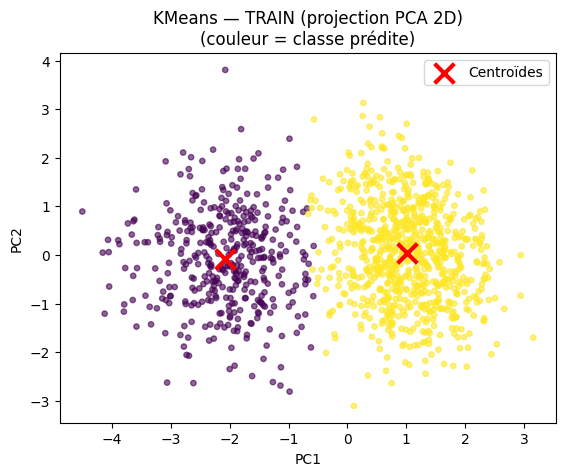

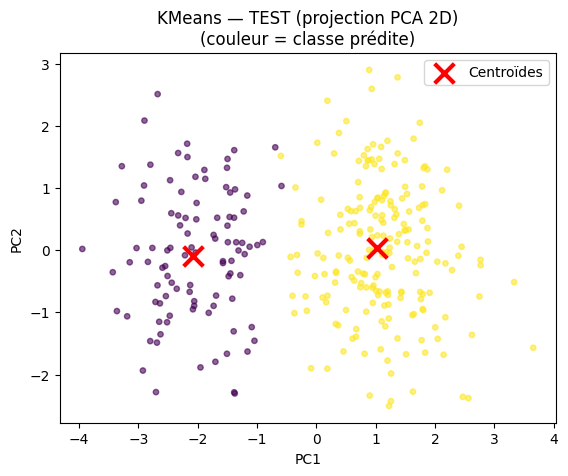

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

# -------- 0) Données --------
df = df.copy()
y = df['is_genuine'].astype(int)

features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
X = df[features]

# -------- 1) Split train / test --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
n_train, n_test = len(X_train), len(X_test)
print(f"Volumes -> train: {n_train} | test: {n_test}")

# -------- 2) Prétraitement (imputation + standardisation) --------
imp = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_pp = scaler.fit_transform(imp.fit_transform(X_train))
X_test_pp  = scaler.transform(imp.transform(X_test))

# -------- 2bis) Méthode du coude pour choisir K --------
inertias = []
K_range = range(1, 11)  # par ex. de 1 à 10 clusters

for k in K_range:
    km_tmp = KMeans(n_clusters=k, n_init=20, random_state=42)
    km_tmp.fit(X_train_pp)
    inertias.append(km_tmp.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (somme des distances au centre)")
plt.title("Méthode du coude pour KMeans (données train)")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

# -------- 3) KMeans (K=2) --------
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_train = kmeans.fit_predict(X_train_pp)   # clusters sur train
labels_test  = kmeans.predict(X_test_pp)        # clusters sur test
print("Itérations KMeans (convergence):", kmeans.n_iter_)

# -------- 4) Matrices de contingence brutes (vrai vs cluster) --------
cont_train_raw = pd.crosstab(y_train, labels_train, rownames=['true'], colnames=['cluster'])
cont_test_raw  = pd.crosstab(y_test,  labels_test,  rownames=['true'], colnames=['cluster'])
print("\n[Contingence TRAIN - true vs cluster]\n", cont_train_raw)
print("\n[Contingence TEST  - true vs cluster]\n",  cont_test_raw)

# -------- 5) Mapper les clusters -> classes (Hungarian sur la contingence train) --------
cost = cont_train_raw.max().max() - cont_train_raw.values   # transformer en "coûts"
row_ind, col_ind = linear_sum_assignment(cost)
mapping = {col_ind[i]: cont_train_raw.index[row_ind[i]] for i in range(len(row_ind))}
print("\nMapping cluster->classe (dérivé sur TRAIN):", mapping)

# Prédictions 'supervisées' (après mapping)
pred_train = np.vectorize(mapping.get)(labels_train)
pred_test  = np.vectorize(mapping.get)(labels_test)

# -------- 6) Matrices de contingence après mapping (≃ confusion matrices) --------
cont_train = pd.crosstab(y_train, pred_train, rownames=['true'], colnames=['pred'])
cont_test  = pd.crosstab(y_test,  pred_test,  rownames=['true'], colnames=['pred'])
print("\n[Contingence/Confusion TRAIN - true vs pred]\n", cont_train)
print("\n[Contingence/Confusion TEST  - true vs pred]\n",  cont_test)

# -------- 7) Accuracy --------
acc_train = (pred_train == y_train.values).mean()
acc_test  = (pred_test  == y_test.values).mean()
print(f"\nAccuracy TRAIN: {acc_train:.3f}")
print(f"Accuracy TEST : {acc_test:.3f}")

# -------- 8) Répartition des VRAIES classes et des PRÉDICTIONS --------
print("\nRépartition vraies classes (train):")
print(y_train.value_counts().sort_index())
print("\nRépartition vraies classes (test):")
print(y_test.value_counts().sort_index())

print("\nRépartition PRÉDITES (train):")
print(pd.Series(pred_train).value_counts().sort_index())
print("\nRépartition PRÉDITES (test):")
print(pd.Series(pred_test).value_counts().sort_index())

# -------- 9) Scatter plots (PCA 2D) --------
# PCA entraînée sur le TRAIN (puis appliquée au TEST) pour visualiser en 2D
pca = PCA(n_components=2, random_state=42)
Z_train = pca.fit_transform(X_train_pp)
Z_test  = pca.transform(X_test_pp)

# Projeter les centroïdes dans l'espace PCA
centroids_2d = pca.transform(kmeans.cluster_centers_)

# Plot TRAIN (couleur = classe prédite après mapping)
plt.figure()
plt.scatter(Z_train[:, 0], Z_train[:, 1], c=pred_train, alpha=0.6, s=15)
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='x', s=200, linewidths=3, c='red', label='Centroïdes'
)
plt.title("KMeans — TRAIN (projection PCA 2D)\n(couleur = classe prédite)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.show()

# Plot TEST
plt.figure()
plt.scatter(Z_test[:, 0], Z_test[:, 1], c=pred_test, alpha=0.6, s=15)
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='x', s=200, linewidths=3, c='red', label='Centroïdes'
)
plt.title("KMeans — TEST (projection PCA 2D)\n(couleur = classe prédite)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.show()


# Regression logistique

Volumes -> train: 1200 | test: 300
Itérations (solver): [10]

[Contingence/Confusion TRAIN]
 pred    0    1
true          
0     393    7
1       2  798

[Contingence/Confusion TEST]
 pred   0    1
true         
0     98    2
1      1  199

Accuracy TRAIN: 0.993
Accuracy TEST : 0.990

Répartition vraies classes (train):
is_genuine
1    800
0    400
Name: count, dtype: int64

Répartition vraies classes (test):
is_genuine
1    200
0    100
Name: count, dtype: int64

Répartition PRÉDITES (train):
1    805
0    395
Name: count, dtype: int64

Répartition PRÉDITES (test):
1    201
0     99
Name: count, dtype: int64


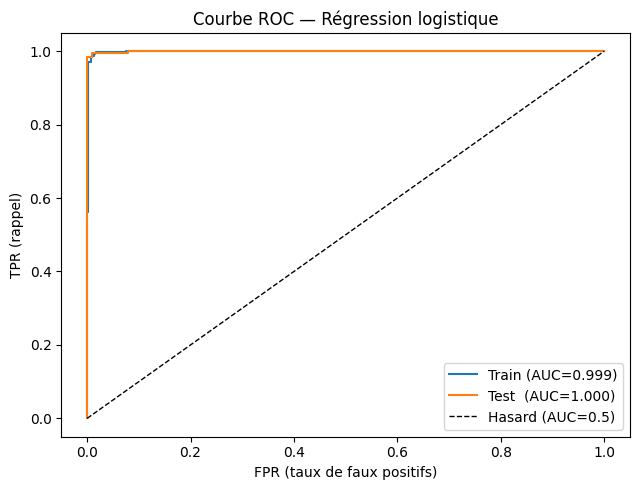

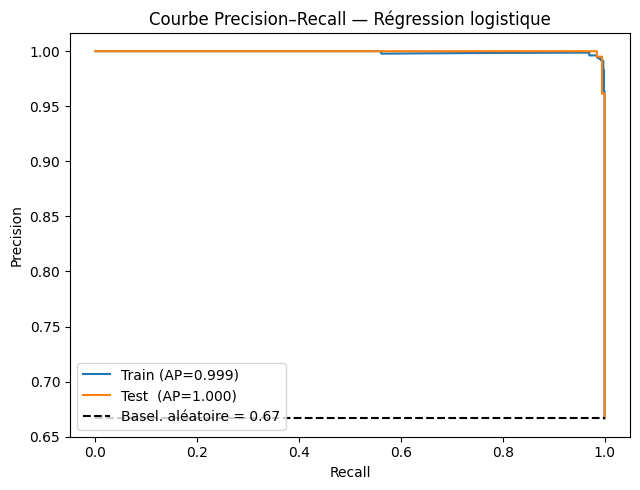

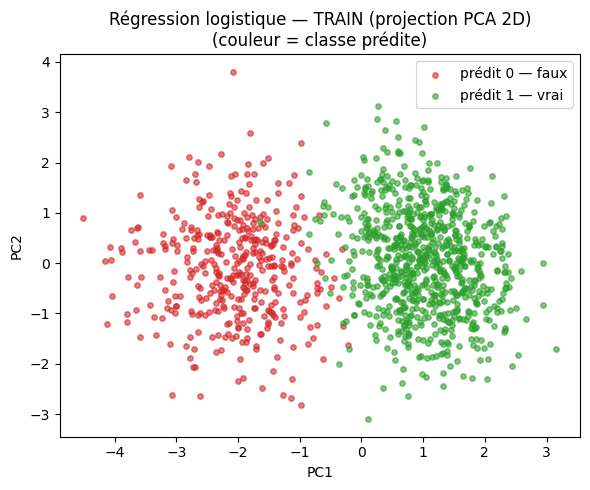

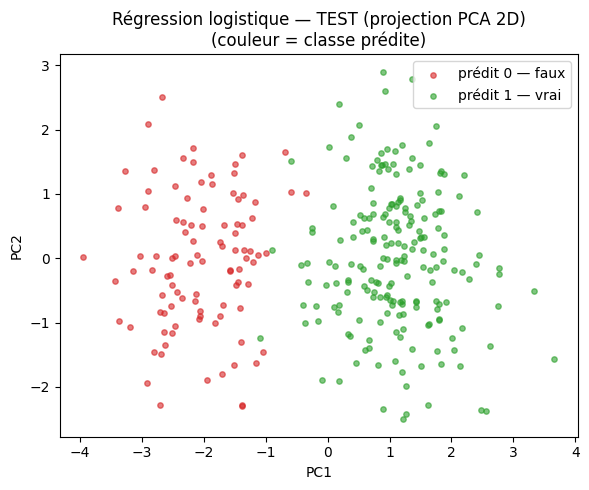

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

# --- 0) Colonnes ---
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
target   = 'is_genuine'

y = df[target].astype(int)

# --- 1) Split train/test (stratifié) ---
X_train, X_test, y_train, y_test = train_test_split(
    df[features], y, test_size=0.2, random_state=42, stratify=y
)
print(f"Volumes -> train: {len(X_train)} | test: {len(X_test)}")

# --- 2) Pipeline: impute (médiane) + scale + régression logistique ---
clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))  # option: class_weight='balanced'
])
clf.fit(X_train, y_train)

# itérations du solveur
print("Itérations (solver):", clf.named_steps['logreg'].n_iter_)

# --- 3) Scores et matrices (seuil 0.5) ---
proba_train = clf.predict_proba(X_train)[:, 1]
proba_test  = clf.predict_proba(X_test)[:, 1]

y_pred_train = (proba_train >= 0.5).astype(int)
y_pred_test  = (proba_test  >= 0.5).astype(int)

cm_train = pd.crosstab(y_train, y_pred_train, rownames=['true'], colnames=['pred'])
cm_test  = pd.crosstab(y_test,  y_pred_test,  rownames=['true'], colnames=['pred'])
print("\n[Contingence/Confusion TRAIN]\n", cm_train)
print("\n[Contingence/Confusion TEST]\n",  cm_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
print(f"\nAccuracy TRAIN: {acc_train:.3f}")
print(f"Accuracy TEST : {acc_test:.3f}")

# Répartitions (demandées)
print("\nRépartition vraies classes (train):")
print(y_train.value_counts())
print("\nRépartition vraies classes (test):")
print(y_test.value_counts())

print("\nRépartition PRÉDITES (train):")
print(pd.Series(y_pred_train).value_counts())
print("\nRépartition PRÉDITES (test):")
print(pd.Series(y_pred_test).value_counts())

# --- 4) Courbes ROC (train & test) ---
fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  proba_test)
auc_tr = roc_auc_score(y_train, proba_train)
auc_te = roc_auc_score(y_test,  proba_test)

plt.figure(figsize=(6.5,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test  (AUC={auc_te:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1, label="Hasard (AUC=0.5)")
plt.xlabel("FPR (taux de faux positifs)")
plt.ylabel("TPR (rappel)")
plt.title("Courbe ROC — Régression logistique")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# --- 5) Courbes Precision–Recall (train & test) ---
prec_tr, rec_tr, _ = precision_recall_curve(y_train, proba_train)
prec_te, rec_te, _ = precision_recall_curve(y_test,  proba_test)
ap_tr = average_precision_score(y_train, proba_train)
ap_te = average_precision_score(y_test,  proba_test)

baseline = y_test.mean()  # prévalence des positifs (classe 1)

plt.figure(figsize=(6.5,5))
plt.plot(rec_tr, prec_tr, label=f"Train (AP={ap_tr:.3f})")
plt.plot(rec_te, prec_te, label=f"Test  (AP={ap_te:.3f})")
plt.hlines(baseline, 0, 1, colors='k', linestyles='--',
           label=f"Basel. aléatoire = {baseline:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision–Recall — Régression logistique")
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

# --- 6) (Optionnel) Scatter 2D des prédictions (comme KMeans) ---
# Projection PCA juste pour visuel (pas pour l'entraînement)
pca = PCA(n_components=2, random_state=42)
X_tr_2d = pca.fit_transform(clf[:-1].transform(X_train))  # uniquement preproc
X_te_2d = pca.transform(clf[:-1].transform(X_test))

palette = {0: 'tab:red', 1: 'tab:green'}
for split, XY, yhat in [('TRAIN', X_tr_2d, y_pred_train), ('TEST', X_te_2d, y_pred_test)]:
    plt.figure(figsize=(6,5))
    for lab in [0,1]:
        m = (yhat == lab)
        plt.scatter(XY[m,0], XY[m,1], s=15, alpha=0.6, c=palette[lab],
                    label=f"prédit {lab} — {'faux' if lab==0 else 'vrai'}")
    plt.title(f"Régression logistique — {split} (projection PCA 2D)\n(couleur = classe prédite)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()


# KNN

Volumes -> train: 1200 | test: 300

[Contingence/Confusion TRAIN]
 pred    0    1
true          
0     400    0
1       0  800

[Contingence/Confusion TEST]
 pred   0    1
true         
0     98    2
1      1  199

Accuracy TRAIN: 1.000
Accuracy TEST : 0.990

Répartition vraies classes (train):
is_genuine
1    800
0    400
Name: count, dtype: int64

Répartition vraies classes (test):
is_genuine
1    200
0    100
Name: count, dtype: int64

Répartition PRÉDITES (train):
1    800
0    400
Name: count, dtype: int64

Répartition PRÉDITES (test):
1    201
0     99
Name: count, dtype: int64


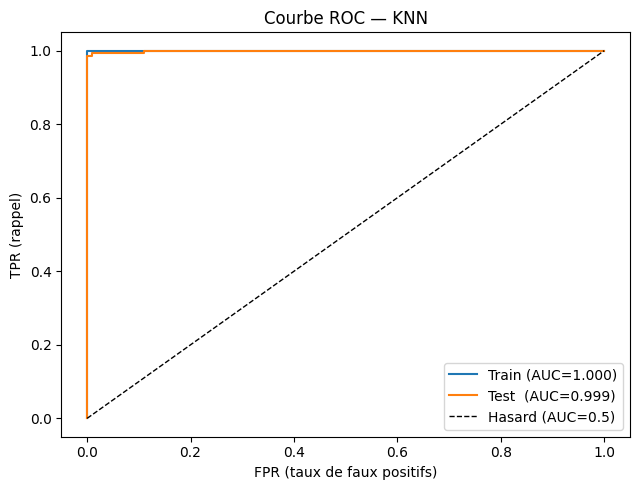

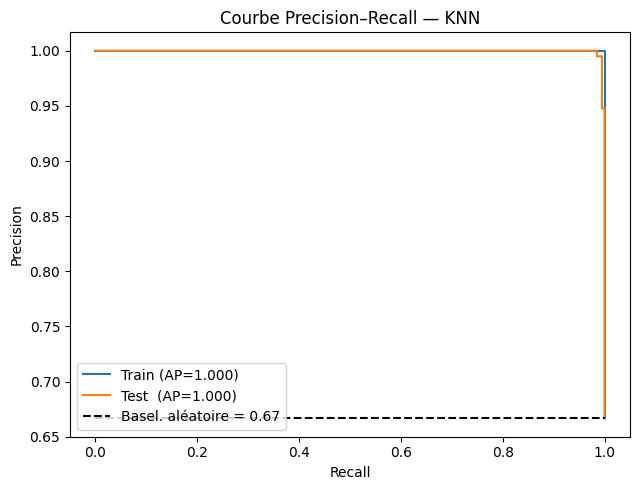

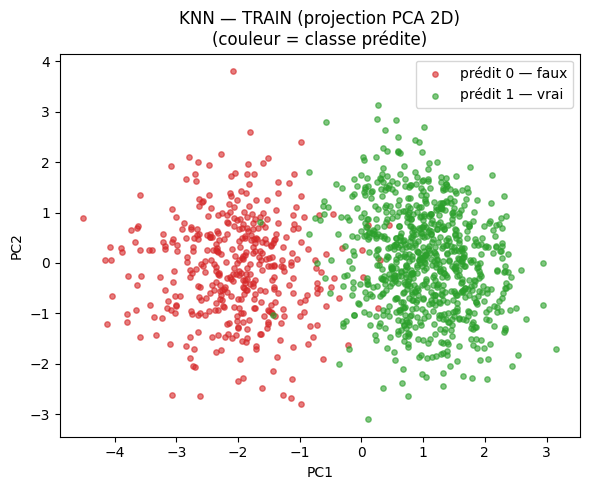

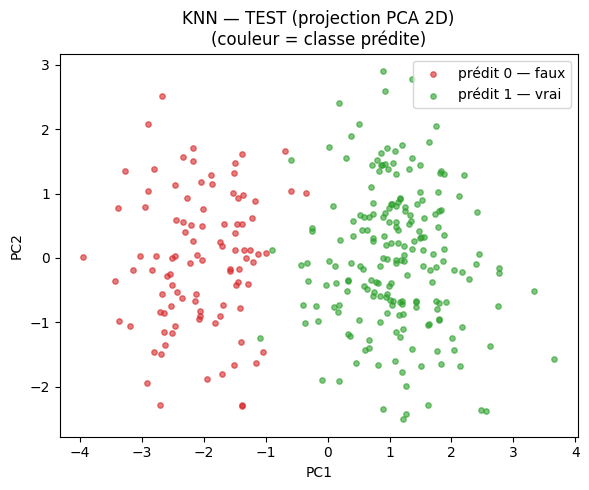

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

# --- 0) Colonnes ---
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
target   = 'is_genuine'
y = df[target].astype(int)

# --- 1) Split train/test (stratifié) ---
X_train, X_test, y_train, y_test = train_test_split(
    df[features], y, test_size=0.2, random_state=42, stratify=y
)
print(f"Volumes -> train: {len(X_train)} | test: {len(X_test)}")

# --- 2) Pipeline: impute (médiane) + scale + KNN ---
knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance'))  # à tuner
])
knn.fit(X_train, y_train)

# --- 3) Scores et matrices (seuil 0.5) ---
proba_train = knn.predict_proba(X_train)[:, 1]
proba_test  = knn.predict_proba(X_test)[:, 1]

y_pred_train = (proba_train >= 0.5).astype(int)
y_pred_test  = (proba_test  >= 0.5).astype(int)

cm_train = pd.crosstab(y_train, y_pred_train, rownames=['true'], colnames=['pred'])
cm_test  = pd.crosstab(y_test,  y_pred_test,  rownames=['true'], colnames=['pred'])
print("\n[Contingence/Confusion TRAIN]\n", cm_train)
print("\n[Contingence/Confusion TEST]\n",  cm_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
print(f"\nAccuracy TRAIN: {acc_train:.3f}")
print(f"Accuracy TEST : {acc_test:.3f}")

# Répartitions
print("\nRépartition vraies classes (train):")
print(y_train.value_counts())
print("\nRépartition vraies classes (test):")
print(y_test.value_counts())

print("\nRépartition PRÉDITES (train):")
print(pd.Series(y_pred_train).value_counts())
print("\nRépartition PRÉDITES (test):")
print(pd.Series(y_pred_test).value_counts())

# --- 4) Courbes ROC (train & test) ---
fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  proba_test)
auc_tr = roc_auc_score(y_train, proba_train)
auc_te = roc_auc_score(y_test,  proba_test)

plt.figure(figsize=(6.5,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test  (AUC={auc_te:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1, label="Hasard (AUC=0.5)")
plt.xlabel("FPR (taux de faux positifs)")
plt.ylabel("TPR (rappel)")
plt.title("Courbe ROC — KNN")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# --- 5) Courbes Precision–Recall (train & test) ---
prec_tr, rec_tr, _ = precision_recall_curve(y_train, proba_train)
prec_te, rec_te, _ = precision_recall_curve(y_test,  proba_test)
ap_tr = average_precision_score(y_train, proba_train)
ap_te = average_precision_score(y_test,  proba_test)
baseline = y_test.mean()

plt.figure(figsize=(6.5,5))
plt.plot(rec_tr, prec_tr, label=f"Train (AP={ap_tr:.3f})")
plt.plot(rec_te, prec_te, label=f"Test  (AP={ap_te:.3f})")
plt.hlines(baseline, 0, 1, colors='k', linestyles='--',
           label=f"Basel. aléatoire = {baseline:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision–Recall — KNN")
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

# --- 6) (Optionnel) Scatter 2D des prédictions (projection PCA) ---
# On projette les données après prétraitements (impute + scale)
pca = PCA(n_components=2, random_state=42)
X_tr_2d = pca.fit_transform(knn[:-1].transform(X_train))
X_te_2d = pca.transform(knn[:-1].transform(X_test))

palette = {0: 'tab:red', 1: 'tab:green'}
for split, XY, yhat in [('TRAIN', X_tr_2d, y_pred_train), ('TEST', X_te_2d, y_pred_test)]:
    plt.figure(figsize=(6,5))
    for lab in [0,1]:
        m = (yhat == lab)
        plt.scatter(XY[m,0], XY[m,1], s=15, alpha=0.6, c=palette[lab],
                    label=f"prédit {lab} — {'faux' if lab==0 else 'vrai'}")
    plt.title(f"KNN — {split} (projection PCA 2D)\n(couleur = classe prédite)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()



# Random Forest

Volumes -> train: 1200 | test: 300
Forêt : RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                       n_jobs=-1, random_state=42)

[Contingence/Confusion TRAIN]
 pred    0    1
true          
0     400    0
1       0  800

[Contingence/Confusion TEST]
 pred   0    1
true         
0     98    2
1      1  199

Accuracy TRAIN: 1.000
Accuracy TEST : 0.990

Répartition vraies classes (train):
is_genuine
1    800
0    400
Name: count, dtype: int64

Répartition vraies classes (test):
is_genuine
1    200
0    100
Name: count, dtype: int64

Répartition PRÉDITES (train):
1    800
0    400
Name: count, dtype: int64

Répartition PRÉDITES (test):
1    201
0     99
Name: count, dtype: int64


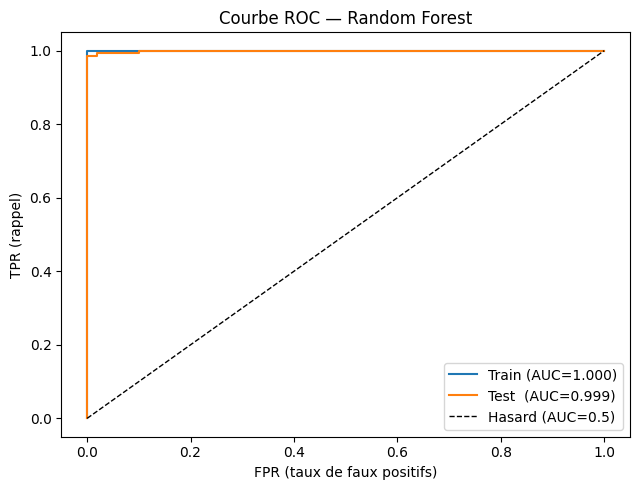

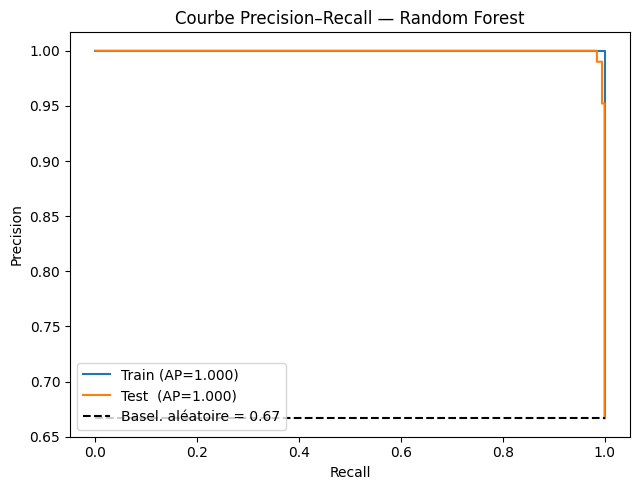

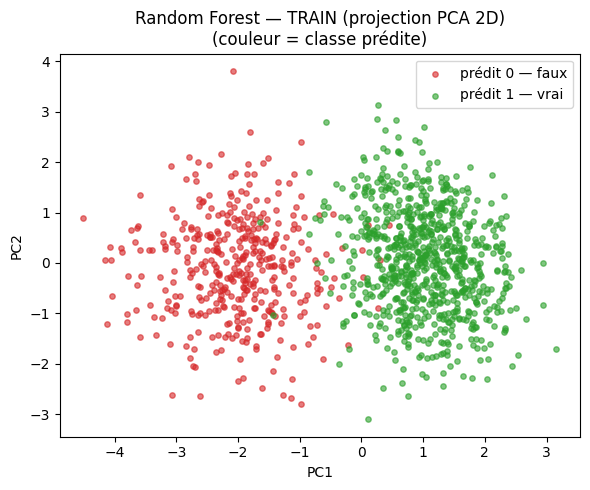

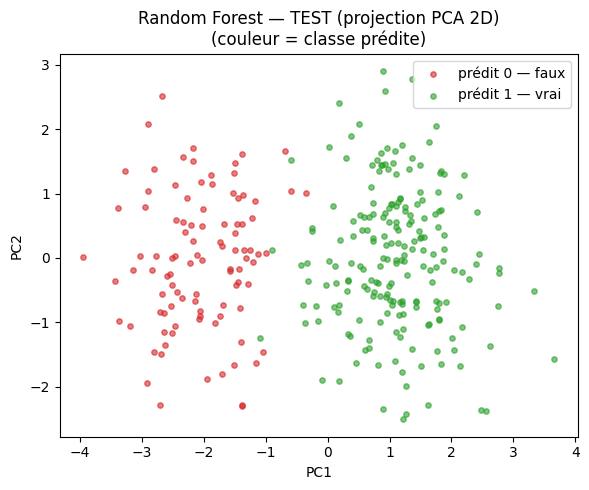


Importances de caractéristiques :
 length          0.486
margin_low      0.298
margin_up       0.121
height_right    0.054
height_left     0.033
diagonal        0.008
dtype: float64


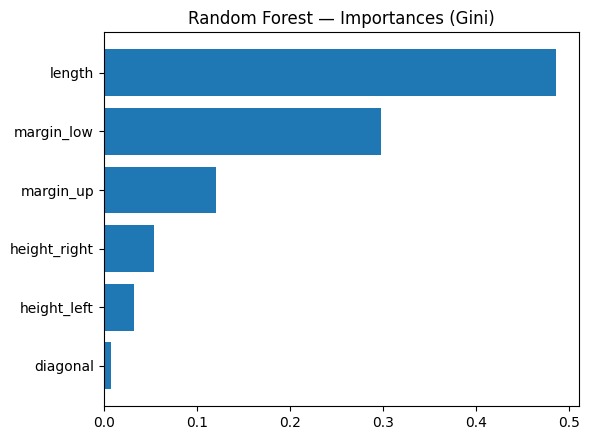

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

# --- 0) Colonnes ---
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
target   = 'is_genuine'
y = df[target].astype(int)

# --- 1) Split train/test (stratifié) ---
X_train, X_test, y_train, y_test = train_test_split(
    df[features], y, test_size=0.2, random_state=42, stratify=y
)
print(f"Volumes -> train: {len(X_train)} | test: {len(X_test)}")

# --- 2) Pipeline: impute (médiane) + (scale optionnel) + Random Forest ---
rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),  # pas nécessaire pour les arbres, gardé pour symétrie & PCA
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced_subsample'  # utile si léger déséquilibre
    ))
])
rf.fit(X_train, y_train)

# (Pas d'itérations comme pour la logistique)
print("Forêt :", rf.named_steps['rf'])

# --- 3) Scores et matrices (seuil 0.5) ---
proba_train = rf.predict_proba(X_train)[:, 1]
proba_test  = rf.predict_proba(X_test)[:, 1]

y_pred_train = (proba_train >= 0.5).astype(int)
y_pred_test  = (proba_test  >= 0.5).astype(int)

cm_train = pd.crosstab(y_train, y_pred_train, rownames=['true'], colnames=['pred'])
cm_test  = pd.crosstab(y_test,  y_pred_test,  rownames=['true'], colnames=['pred'])
print("\n[Contingence/Confusion TRAIN]\n", cm_train)
print("\n[Contingence/Confusion TEST]\n",  cm_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
print(f"\nAccuracy TRAIN: {acc_train:.3f}")
print(f"Accuracy TEST : {acc_test:.3f}")

# Répartitions
print("\nRépartition vraies classes (train):")
print(y_train.value_counts())
print("\nRépartition vraies classes (test):")
print(y_test.value_counts())

print("\nRépartition PRÉDITES (train):")
print(pd.Series(y_pred_train).value_counts())
print("\nRépartition PRÉDITES (test):")
print(pd.Series(y_pred_test).value_counts())

# --- 4) Courbes ROC (train & test) ---
fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  proba_test)
auc_tr = roc_auc_score(y_train, proba_train)
auc_te = roc_auc_score(y_test,  proba_test)

plt.figure(figsize=(6.5,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test  (AUC={auc_te:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1, label="Hasard (AUC=0.5)")
plt.xlabel("FPR (taux de faux positifs)")
plt.ylabel("TPR (rappel)")
plt.title("Courbe ROC — Random Forest")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# --- 5) Courbes Precision–Recall (train & test) ---
prec_tr, rec_tr, _ = precision_recall_curve(y_train, proba_train)
prec_te, rec_te, _ = precision_recall_curve(y_test,  proba_test)
ap_tr = average_precision_score(y_train, proba_train)
ap_te = average_precision_score(y_test,  proba_test)

baseline = y_test.mean()  # prévalence de la classe 1

plt.figure(figsize=(6.5,5))
plt.plot(rec_tr, prec_tr, label=f"Train (AP={ap_tr:.3f})")
plt.plot(rec_te, prec_te, label=f"Test  (AP={ap_te:.3f})")
plt.hlines(baseline, 0, 1, colors='k', linestyles='--',
           label=f"Basel. aléatoire = {baseline:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision–Recall — Random Forest")
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

# --- 6) (Optionnel) Scatter 2D des prédictions (projection PCA) ---
pca = PCA(n_components=2, random_state=42)
X_tr_2d = pca.fit_transform(rf[:-1].transform(X_train))  # uniquement prétraitements
X_te_2d = pca.transform(rf[:-1].transform(X_test))

palette = {0: 'tab:red', 1: 'tab:green'}
for split, XY, yhat in [('TRAIN', X_tr_2d, y_pred_train), ('TEST', X_te_2d, y_pred_test)]:
    plt.figure(figsize=(6,5))
    for lab in [0,1]:
        m = (yhat == lab)
        plt.scatter(XY[m,0], XY[m,1], s=15, alpha=0.6, c=palette[lab],
                    label=f"prédit {lab} — {'faux' if lab==0 else 'vrai'}")
    plt.title(f"Random Forest — {split} (projection PCA 2D)\n(couleur = classe prédite)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()

# --- 7) (Optionnel) Importance des variables ---
imp = pd.Series(rf.named_steps['rf'].feature_importances_, index=features).sort_values(ascending=True)
print("\nImportances de caractéristiques :\n", imp.sort_values(ascending=False).round(3))
plt.figure(figsize=(6,4.5))
plt.barh(imp.index, imp.values)
plt.title("Random Forest — Importances (Gini)")
plt.tight_layout()
plt.show()


# Mise en production

# Préparation de la data

In [ ]:
# On garde la même liste de features que pour l'entraînement
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']

# Chargement du fichier de production
df_prod = pd.read_csv('billets_production.csv', sep=',')
df_prod.head()

,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


# Regression Logistique

In [ ]:
# 1) Extraire les variables explicatives
X_prod = df_prod[features]

# 2) Prédire la probabilité d'être authentique (classe 1)
proba_prod = clf.predict_proba(X_prod)[:, 1]

# 3) Appliquer un seuil (0.5 par défaut) pour obtenir la classe prédite
y_pred_prod = (proba_prod >= 0.5).astype(int)

# 4) Ajouter les résultats dans le DataFrame
df_prod['proba_is_genuine'] = proba_prod
df_prod['is_genuine_pred'] = y_pred_prod

df_prod.head()
# 1 = billet vrai ; 0 = billet faux


,diagonal,height_left,height_right,margin_low,margin_up,length,id,proba_is_genuine,is_genuine_pred
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0.001112,0
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0.000243,0
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0.000360,0
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,0.979517,1
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,0.999777,1


# Kmeans

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

import pandas as pd

df = pd.read_csv('billets.csv', sep=';')
df.head()
# -------- 0) Données --------
df = df.copy()
y = df['is_genuine'].astype(int)

features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
X = df[features]

# -------- 1) Split train / test --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
n_train, n_test = len(X_train), len(X_test)


# -------- 2) Prétraitement (imputation + standardisation) --------
# - Imputation médiane (sécurité si NaN) puis StandardScaler (KMeans y est sensible)
imp = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_pp = scaler.fit_transform(imp.fit_transform(X_train))
X_test_pp  = scaler.transform(imp.transform(X_test))

# -------- 3) KMeans (K=2) --------
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_train = kmeans.fit_predict(X_train_pp)   # clusters sur train
labels_test  = kmeans.predict(X_test_pp)        # clusters sur test


# -------- 4) Matrices de contingence brutes (vrai vs cluster) --------
cont_train_raw = pd.crosstab(y_train, labels_train, rownames=['true'], colnames=['cluster'])
cont_test_raw  = pd.crosstab(y_test,  labels_test,  rownames=['true'], colnames=['cluster'])


# -------- 5) Mapper les clusters -> classes (Hungarian sur la contingence train) --------
# On cherche l'affectation cluster->classe qui maximise les bons appariements.
cost = cont_train_raw.max().max() - cont_train_raw.values   # transformer en "coûts"
row_ind, col_ind = linear_sum_assignment(cost)
mapping = {col_ind[i]: cont_train_raw.index[row_ind[i]] for i in range(len(row_ind))}


# Prédictions 'supervisées' (après mapping)
pred_train = np.vectorize(mapping.get)(labels_train)
pred_test  = np.vectorize(mapping.get)(labels_test)

# -------- 6) Matrices de contingence après mapping (≃ confusion matrices) --------
cont_train = pd.crosstab(y_train, pred_train, rownames=['true'], colnames=['pred'])
cont_test  = pd.crosstab(y_test,  pred_test,  rownames=['true'], colnames=['pred'])


# -------- 7) Accuracy --------
acc_train = (pred_train == y_train.values).mean()
acc_test  = (pred_test  == y_test.values).mean()


# 1) Charger la prod avec le bon séparateur
df_prod = pd.read_csv('billets_production.csv', sep=',')  # si ton fichier est séparé par des virgules

# 2) Extraire les mêmes variables explicatives que pour l'entraînement
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
X_prod = df_prod[features]

# 3) Prétraitement avec les objets DÉJÀ entraînés
X_prod_pp = scaler.transform(imp.transform(X_prod))

# 4) Clustering + mapping cluster -> classe
labels_prod = kmeans.predict(X_prod_pp)
pred_prod = np.vectorize(mapping.get)(labels_prod)   # 0 = faux, 1 = vrai

# 5) Ajouter les résultats dans le DataFrame (comme pour la régression logistique)
df_prod['cluster'] = labels_prod            # optionnel, pour voir le cluster brut
df_prod['is_genuine_pred'] = pred_prod      # classe prédite (0/1)

# 6) Afficher un tableau "propre" comme tu le faisais
cols_affichees = ['id'] + features + ['cluster', 'is_genuine_pred']
df_prod[cols_affichees].head()




,id,diagonal,height_left,height_right,margin_low,margin_up,length,cluster,is_genuine_pred
0,A_1,171.76,104.01,103.54,5.21,3.30,111.42,0,0
1,A_2,171.87,104.17,104.13,6.00,3.31,112.09,0,0
2,A_3,172.00,104.58,104.29,4.99,3.39,111.57,0,0
3,A_4,172.49,104.55,104.34,4.44,3.03,113.20,1,1
4,A_5,171.65,103.63,103.56,3.77,3.16,113.33,1,1


# KNN

In [ ]:
# --- 7) Prédictions sur billets_production.csv avec le KNN ---

# Charger la prod (séparateur virgule comme on avait vu)
df_prod = pd.read_csv('billets_production.csv', sep=',')

# Utiliser les mêmes features que pour le train
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
X_prod = df_prod[features]

# Prédire la probabilité d'être authentique (classe 1) avec le pipeline KNN
proba_prod = knn.predict_proba(X_prod)[:, 1]

# Appliquer le seuil 0.5 pour obtenir la classe prédite
y_pred_prod = (proba_prod >= 0.5).astype(int)

# Ajouter les résultats dans le DataFrame
df_prod['proba_is_genuine_knn'] = proba_prod
df_prod['is_genuine_pred_knn'] = y_pred_prod

# Afficher un tableau comme pour la régression logistique
cols_affichees = ['id'] + features + ['proba_is_genuine_knn', 'is_genuine_pred_knn']
df_prod[cols_affichees].head()


,id,diagonal,height_left,height_right,margin_low,margin_up,length,proba_is_genuine_knn,is_genuine_pred_knn
0,A_1,171.76,104.01,103.54,5.21,3.30,111.42,0.0,0
1,A_2,171.87,104.17,104.13,6.00,3.31,112.09,0.0,0
2,A_3,172.00,104.58,104.29,4.99,3.39,111.57,0.0,0
3,A_4,172.49,104.55,104.34,4.44,3.03,113.20,1.0,1
4,A_5,171.65,103.63,103.56,3.77,3.16,113.33,1.0,1


# Random Forest

In [ ]:
# --- 8) Prédictions sur billets_production.csv avec la Random Forest ---

# 1) Charger la prod (on garde sep=',' comme pour les autres modèles)
df_prod = pd.read_csv('billets_production.csv', sep=',')

# 2) Extraire les variables explicatives
features = ['diagonal','height_left','height_right','margin_low','margin_up','length']
X_prod = df_prod[features]

# 3) Prédire la probabilité d'être authentique (classe 1)
proba_prod_rf = rf.predict_proba(X_prod)[:, 1]

# 4) Appliquer un seuil (0.5 par défaut) pour obtenir la classe prédite
y_pred_prod_rf = (proba_prod_rf >= 0.5).astype(int)

# 5) Ajouter les résultats dans le DataFrame
df_prod['proba_is_genuine_rf'] = proba_prod_rf
df_prod['is_genuine_pred_rf'] = y_pred_prod_rf

# 6) Afficher un tableau récap comme pour les autres modèles
cols_affichees = ['id'] + features + ['proba_is_genuine_rf', 'is_genuine_pred_rf']
df_prod[cols_affichees].head()


,id,diagonal,height_left,height_right,margin_low,margin_up,length,proba_is_genuine_rf,is_genuine_pred_rf
0,A_1,171.76,104.01,103.54,5.21,3.30,111.42,0.003333,0
1,A_2,171.87,104.17,104.13,6.00,3.31,112.09,0.000000,0
2,A_3,172.00,104.58,104.29,4.99,3.39,111.57,0.003333,0
3,A_4,172.49,104.55,104.34,4.44,3.03,113.20,0.976667,1
4,A_5,171.65,103.63,103.56,3.77,3.16,113.33,1.000000,1
